# **HW 1: Exploratory Data Analysis and Dimensionality Reduction in Wine Dataset**
**HW Due date is 02/11/2025, 2:00 pm**

In this assignment, you will analyze the Wine dataset, which contains the results of a chemical analysis of wines grown in a specific region in Italy, derived from three different cultivars (classes). The dataset consists of various chemical properties present in the wines, making it suitable for classification and clustering tasks.

The goals of this assignment are to perform exploratory data analysis (EDA),handle missing data, standardize the data, and apply dimensionality reduction techniques to understand the underlying structure of the dataset.

# The Wine Dataset:`
The dataset consists of the following features:

* Alcohol: The alcohol content of the wine.
* Malic Acid: The malic acid content of the wine.
* Ash: The ash content of the wine.
* Alcalinity of Ash: The amount of ash that results after burning.
* Magnesium: The magnesium content of the wine.
* Total Phenols: The total phenolic content of the wine.
* Flavanoids: The flavonoid content of the wine.
* Nonflavanoid Phenols: The non-flavonoid phenolic content of the wine.
* Proanthocyanins: The proanthocyanin content of the wine.
* Color Intensity: The intensity of color in the wine.
* Hue: The hue of the wine.
* OD280/OD315 of Diluted Wines: The ratio of optical density measurements at 280nm and 315nm of the wine.
* Proline: The proline content of the wine.

Each row in the dataset represents a wine sample, and the target variable is the cultivar (class) of the wine. There are three classes in total, representing three different types of wines.



# Data Loading and Preprocessing:
* Load the Wine dataset into a DataFrame.
* Standardize the data: Standardize the features by subtracting the mean and dividing by the standard deviation.

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from numpy.linalg import svd

In [ ]:
# Load the Wine dataset
wine_data = load_wine()
X = wine_data.data
y = wine_data.target
feature_names = wine_data.feature_names

**Coding excersice:** Convert the dataset to a DataFrame and display the first few rows of the dataset.

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from numpy.linalg import svd

# Load the Wine dataset
wine_data = load_wine()
X = wine_data.data
y = wine_data.target
feature_names = wine_data.feature_names

# Convert the dataset to a DataFrame
## Your code starts here
df = pd.DataFrame(data=wine_data.data, columns=wine_data.feature_names)
## Your code ends here

# Display the first few rows of the dataset
## Your code starts here
df_first_4 = df.head(4)
print(df_first_4)
## Your code ends here

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   

   od280/od315_of_diluted_wines  proline  
0                          3.92   1065.0  
1                          3.40   1050.0  
2                          3.17   1185.0  
3                          3.45   1480.0  


# Data Quality Issues:
We artificially impose the following data quality issues to the original dataset. Then use the mean, median and iterative methods to recover the missing values and calculate the mean square error!

**Note:** You need to import IterativeImputer module from fancyimpute library. You might need to run "pip install fancyimpute"

**Note:**
'*SimpleImputer*' is a class provided by scikit-learn for handling missing values in datasets. It provides a simple strategy to impute missing values using the mean, median, most frequent, or constant value of the respective columns.

In [3]:
from sklearn.impute import SimpleImputer # for mean/median imputation
from sklearn.metrics import mean_squared_error # to calculate mean squared error
from math import sqrt # for RMSE calculation
from fancyimpute import IterativeImputer # for more advanced imputation

# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine

# Load the Wine dataset
wine_data = load_wine()

# Convert the dataset to a DataFrame
## Your code starts here
df = pd.DataFrame(data=wine_data.data, columns=wine_data.feature_names)
## Your code ends here

# make a copy of the original dataframe
df_original = df.copy()

# Introduce missing values in the dataset for demonstration purposes
# Replace some values with NaN to simulate missing data
df.iloc[10:15, 0] = np.nan # Replacing values in column 0 from index 10 to 15 with NaN
df.iloc[20:25, 1] = np.nan # Replacing values in column 1 from index 20 to 25 with NaN
df.iloc[30:35, 2] = np.nan # Replacing values in column 3 from index 30 to 35 with NaN

# Handling missing values using different methods and calculating RMSE
imputation_methods = ['mean', 'median', 'iterative']
# Write a code to print out the rmse metric for each strategy
## Your code starts here
'''
if method in ['mean', 'median']:
    imputers = SimpleImputer(strategy = method) 
else:
    imputers = IterativeImputer()
'''
imputers = {
    'mean': SimpleImputer(missing_values=np.nan, strategy='mean'), #  Replaces NaNs with the column mean.
    'median': SimpleImputer(missing_values=np.nan, strategy='median'), # Replaces NaNs with the column median.
    'iterative': IterativeImputer() # Predicts missing values based on relationships between features.
}

for method in imputation_methods:
    imputer = imputers[method] # # Select the imputer for the current method
    df_imputed = df.copy() 
    df_imputed.iloc[:, :] = imputer.fit_transform(df_imputed)
    rmse_result = sqrt(mean_squared_error(df_original, df_imputed)) # # Apply imputation
    print(f'RMSE for {method} imputation: {rmse_result:.4f}') 
    
## Your code ends here

RMSE for mean imputation: 0.0733
RMSE for median imputation: 0.0714
RMSE for iterative imputation: 0.0447


**Question:** Which method works best? Why do you think is that?

**You Answer:** The iterative imputation method works best. This is because lower RMSE values mean that the model makes more accurate predictions and fits the data well.

---

# Data Visualization:
**Coding excersice:** Use a box plot to visualize the features of the original data (i.e., dataframe without considering data quality issues)

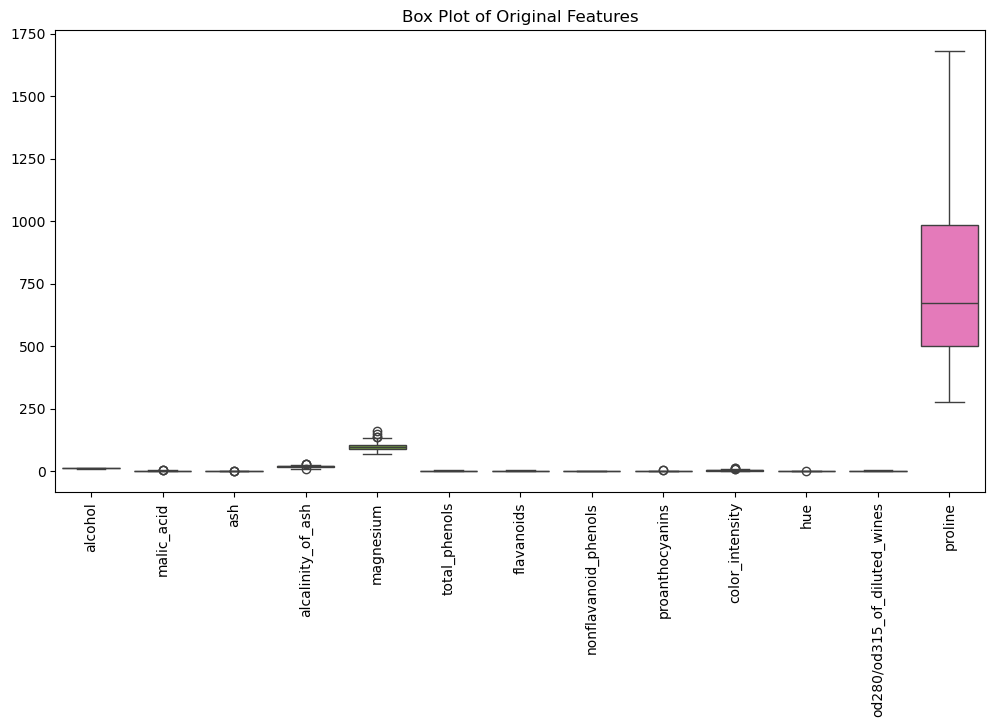

In [5]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

# Load and prepare the dataset
wine_data = load_wine()
df = pd.DataFrame(data=wine_data.data, columns=wine_data.feature_names)

# make a copy of the original dataframe
df_original = df.copy()

# Exploratory Data Analysis
# Visualize key statistics
## Your code starts here
plt.figure(figsize=(12, 6)) # Set figure size
sns.boxplot(data=df_original) # Create a box plot for the dataset
plt.xticks(rotation=90) # Rotate the x-axis about 90 degree
plt.title("Box Plot of Original Features")
plt.show() # Display the plot
## Your code ends here

**Question:** What do you see? What is the problem?

**You Answer:** The boxplot of all the wines, except for proline, are condense which make it difficult to assess data.

---



# Data Standardization:
**Coding excersice:** Standardize the original data (i.e., dataframe without considering data quality issues) and use the same boxplot to visualize the standardized data!

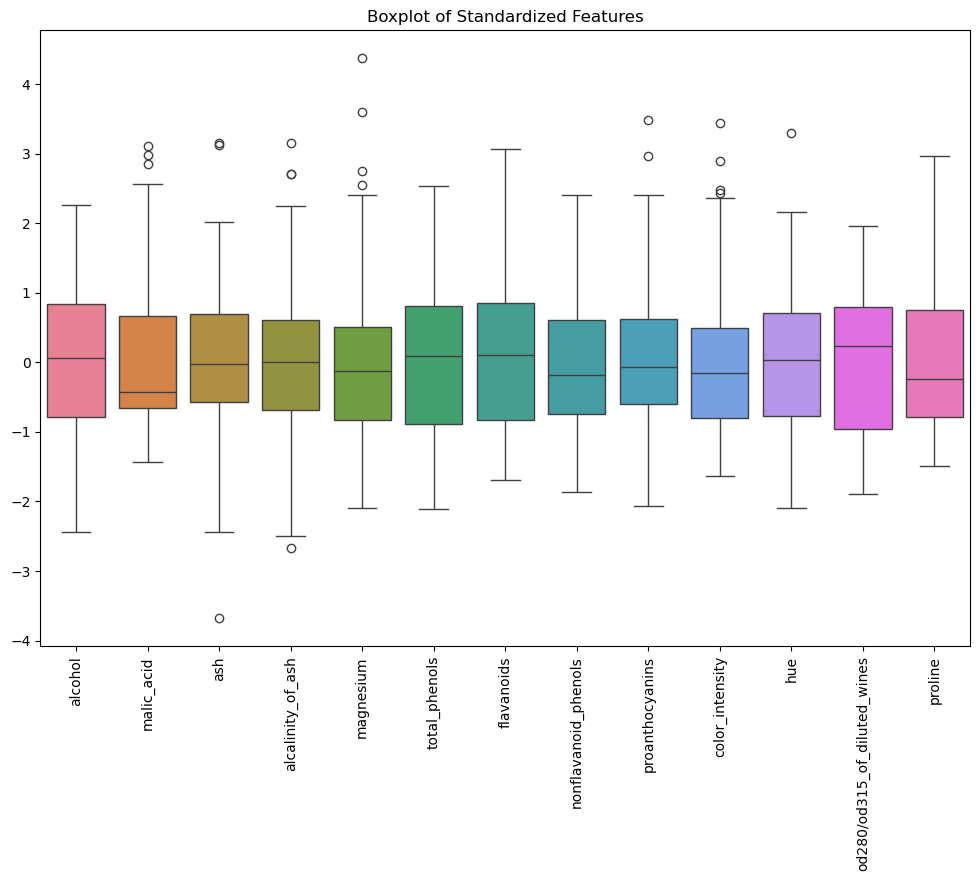

In [7]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

# Load and prepare the dataset
wine_data = load_wine()
df = pd.DataFrame(data=wine_data.data, columns=wine_data.feature_names)

# Standardize the data
""" Put the standardized data back into dataframe"""
## Your code starts here
scaler = StandardScaler()
df_standardized = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

## Your code ends here
    
# Exploratory Data Analysis
# Visualize key statistics
""" Use boxplot to show visualize the standardized features """
## Your code starts here
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_standardized)
plt.xticks(rotation=90)  # Rotate the x-axis
plt.title("Boxplot of Standardized Features")
plt.show()
## Your code ends here

In [ ]:
**Question:** Was the problem resolved?

**You Answer:** Yes!

---


**Coding excersice:** Calculate correlation matrix and visualize it?

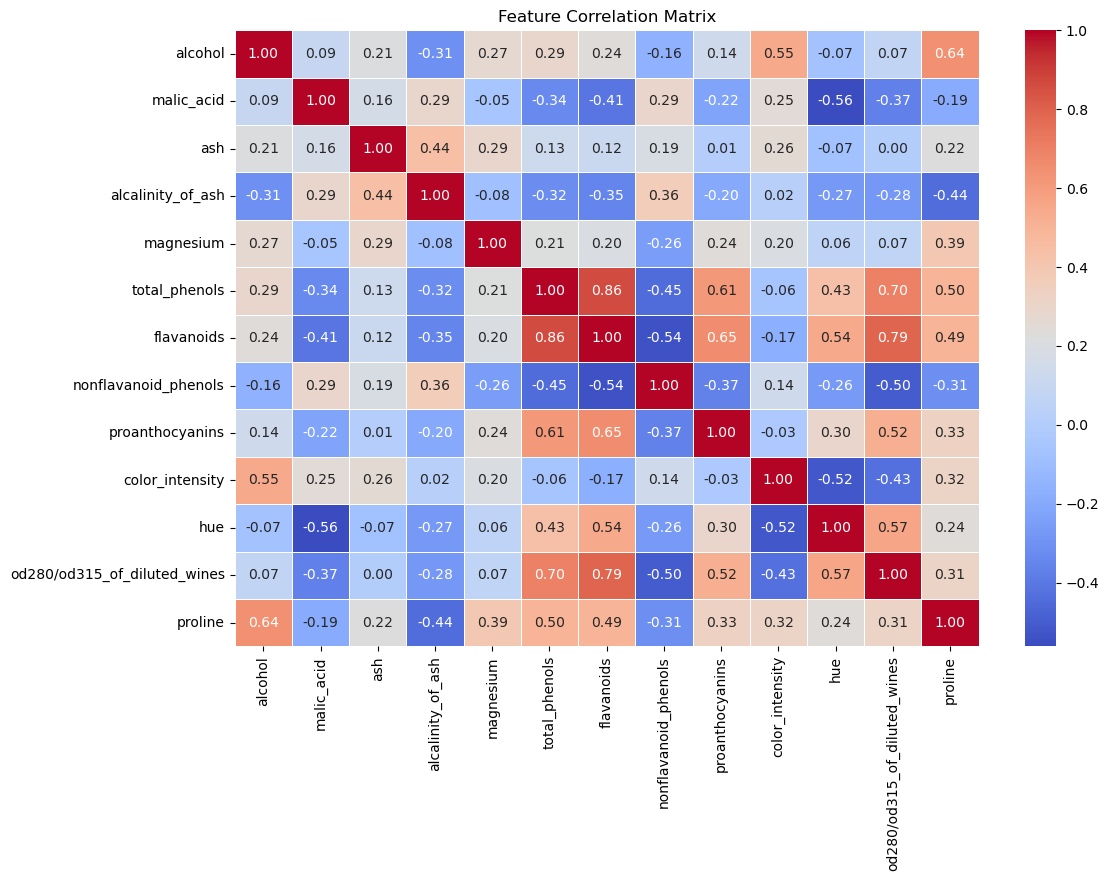

In [9]:
# Import necessary libraries
import numpy as np # Provides support for numerical computations.
import pandas as pd # Used for handling structured data (DataFrame).
import matplotlib.pyplot as plt # Used for creating visualizations (like plots).
import seaborn as sns # A visualization library that makes plots more visually appealing.
from sklearn.datasets import load_wine # Loads the built-in Wine dataset, a commonly used dataset in machine learning.

# Load and prepare the dataset
wine_data = load_wine()
df = pd.DataFrame(data=wine_data.data, columns=wine_data.feature_names)

# Calculate correlation matrix
## Your code starts here
correlation_matrix = df.corr()

# Visualize correlation matrix
plt.figure(figsize=(12, 8)) # Creates a new figure for the plot with dimensions 12x8 inches (width x height).
sns.heatmap(correlation_matrix, # Passes the correlation matrix as data.
            annot=True, # Displays numerical values inside each cell.
            cmap='coolwarm', 
            fmt=".2f", # Formats numbers to 2 decimal places.
            linewidths=0.5) # Adds thin white lines between cells for better clarity.
plt.title("Feature Correlation Matrix")
plt.xticks(rotation=90)  # Rotate the x-axis
plt.yticks(rotation=0)
plt.show()
## Your code ends here

What is the intuition behind the correlation matrix?

**Your answer:** The intuition is to provides a visual presentation of the correlation between every variable to every other variable in a dataset.

---



# Dimensionality Reduction with PCA
**Coding excersice:** Apply Dimensionality Reduction using PCA. Find the number of principle components to retain using the "explained_variance_ratio". Use the threshold of **0.95** for the cumulative explained variance ratio in order to find the number of principle components.

**Note:** When performing dimensionality reduction using PCA, one of the main considerations is to select the appropriate number of principal components to retain. The explained variance ratio tells us the proportion of variance explained by each principal component. By summing up the explained variance ratios cumulatively, we can see how much of the total variance in the data is explained as we include more principal components.

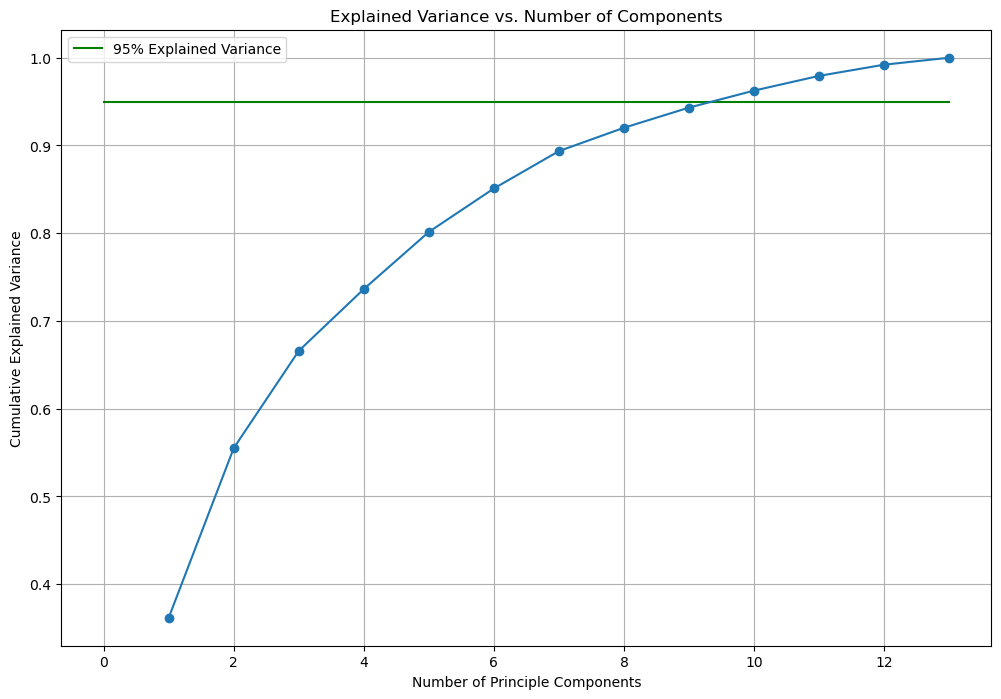

Explained variance ratio of each principal component:
[0.36175413 0.19335431 0.11079959 0.07042714 0.0651282  0.04950682
 0.04260538 0.02659919 0.02297773 0.01935642 0.01680889 0.01274222
 0.00793997]
Summary:
PCA captures 96.2508919303362% of the variance with 10 components.


In [17]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler # Standardizes features (i.e., scales data to zero mean and unit variance).
from sklearn.decomposition import PCA # Principal Component Analysis (PCA) for dimensionality reduction.

# Dimensionality Reduction using PCA
# Apply PCA
## Your code starts here
scaler = StandardScaler() # Initializes a scaler object.
x_scaled = scaler.fit_transform(df_imputed) # Computes the mean & standard deviation of df_imputed (learns scaling parameters).
pca = PCA() # Initializes a PCA object (without specifying components).
x_pca = pca.fit_transform(x_scaled) # Finds principal components from standardized data & Transforms the data into a lower-dimensional space.
## Your code ends here

# Determine the number of principal components to retain
## Your code starts here
variance = pca.explained_variance_ratio_ # Returns the variance ratio explained by each principal component.
variance_exp = np.cumsum(pca.explained_variance_ratio_) # Computes the cumulative sum of explained variance.
## Your code ends here

# Plot explained variance ratio
## Your code starts here
plt.figure(figsize=(12, 8)) # Creates a figure of size 12x8 inches (width x height).
x1 = [0, len(variance_exp)]
y1 = [0.95, 0.95] # # Line at 95% explained variance
plt.plot(x1, y1, color = 'green', label = '95% Explained Variance') # # Draws the 95% threshold line.
plt.plot(range(1, len(variance_exp) + 1), variance_exp, marker = 'o', linestyle = '-')
plt.xlabel("Number of Principle Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs. Number of Components")
plt.legend() # # Displays the legend
plt.grid() # # Adds a grid for readability
plt.show()
## Your code ends here

# Choose the number of components based on the explained variance ratio
## Your code starts here
n_components = np.argmax(variance_exp >= 0.95) + 1 # Finds the first index where cumulative variance reaches at least 0.95.
## Your code ends here

# Perform PCA with the chosen number of components
## Your code starts here
pca = PCA(n_components=n_components) # Initializes PCA with the optimal number of components.
x_pca_final = pca.fit_transform(x_scaled)
## Your code ends here

# Interpretation and Conclusion
# Interpret principal components
print("Explained variance ratio of each principal component:")
## Your code starts here
print(variance)
## Your code ends here

# Summarize key findings
print("Summary:")
""" write your code inside the .format()!"""
print("PCA captures {}% of the variance with {} components.".format(variance_exp[n_components-1]*100, n_components))

**Congratulations!** You completed this assignment.


# Submission Guidelines:

* Implement the above steps in a Jupyter Notebook file.
* Save your ipython code and name it as: lastname_firstname_HW1.ipynb (.ipynb extension)
* Include comments and explanations to describe your approach and the rationale behind each step.
* Submit on Canvas.

